# Split Datasets

Split dataset to Train/Validation/Test sets

## A. Overview

Random split to Train, Validation and Test sets

## B. Combine Datasets

In [1]:
from pathlib import Path
import csv
import os
import random

from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

import configuration
from src import data_utils, setup

random.seed(setup.RANDOM_SEED)

### B.1. Load Original Datasets

In [ ]:
dataset_path = Path("..") / "data"
extended_filepath = dataset_path / "extended"

# Because we will multiply the False samples, base on the original disaster-related dataset,
# so we will sample a fraction of the original dataset to process
df_disaster_sample = pd.read_csv(
    dataset_path / "disaster" / data_utils.INFORMATIVE_FILE
).sample(frac=data_utils.DATA_DISASTER_FRACTION, random_state=setup.RANDOM_SEED)
df_weather_original = pd.read_csv(extended_filepath / data_utils.WEATHER_FILE)
df_out_topic_original = pd.read_csv(extended_filepath / data_utils.OUT_TOPIC_FILE)

In [3]:
print(f"Sampled disaster dataset size: {df_disaster_sample.groupby('informative').size()}")
print(f"Original weather dataset size: {len(df_weather_original)}")
print(f"Original out-topic dataset size: {len(df_out_topic_original)}")

Sampled disaster dataset size: informative
False    30521
True     49344
dtype: int64
Original weather dataset size: 28643
Original out-topic dataset size: 3577546


### B.2. Sample the Original Datasets

In [4]:
def load_datasets(df_disaster_original, df_weather_original, df_out_topic_original, weather_ratio, out_topic_ratio):
    print(f"Weather ratio: {weather_ratio}, Out-topic ratio: {out_topic_ratio}")

    df_weather = df_weather_original.sample(
        frac=weather_ratio, random_state=setup.RANDOM_SEED
    )
    df_out_topic = df_out_topic_original.sample(
        frac=out_topic_ratio, random_state=setup.RANDOM_SEED
    )

    df_informative = pd.concat(
        [df_disaster_original, df_weather, df_out_topic], ignore_index=True
    )
    df_informative = df_informative.sample(
        frac=data_utils.DATA_FRACTION, random_state=setup.RANDOM_SEED
    ).reset_index(drop=True)
    
    return df_informative

def split_then_export_datasets(df_informative, validation_sizes=0.15, test_sizes=0.15, save_path: Path=None):
    df_train, df_validation = train_test_split(
        df_informative,
        test_size=validation_sizes + test_sizes,
        random_state=setup.RANDOM_SEED,
        stratify=df_informative["informative"],
    )
    df_validation, df_test = train_test_split(
        df_validation,
        test_size=test_sizes / (validation_sizes + test_sizes),
        random_state=setup.RANDOM_SEED,
        stratify=df_validation["informative"],
    )
    save_path.mkdir(parents=True, exist_ok=True)
    df_train.to_csv(
        save_path / "informative_train.csv", index=False, quoting=csv.QUOTE_ALL
    )

    df_validation.to_csv(
        save_path / "informative_validation.csv", index=False,quoting=csv.QUOTE_ALL,
    )

    df_test.to_csv(
        save_path / "informative_test.csv", index=False, quoting=csv.QUOTE_ALL
    )
    
    print(len(df_train))
    print(len(df_validation))
    print(len(df_test))

    # ration between train, validation, and test sets
    total = len(df_train) + len(df_validation) + len(df_test)
    print(f"Train: {len(df_train) / total:.2%}")
    print(f"Validation: {len(df_validation) / total:.2%}")
    print(f"Test: {len(df_test) / total:.2%}")
    
    informative_dist = pd.DataFrame({
        "Train": df_train["informative"].value_counts(normalize=True).sort_index(),
        "Validation": df_validation["informative"].value_counts(normalize=True).sort_index(),
        "Test": df_test["informative"].value_counts(normalize=True).sort_index(),
    }).fillna(0)
    
    subset_dist = pd.DataFrame({
        "Train": df_train[["informative", "subset"]].value_counts(normalize=True).sort_index(),
        "Validation": df_validation[["informative", "subset"]].value_counts(normalize=True).sort_index(),
        "Test": df_test[["informative", "subset"]].value_counts(normalize=True).sort_index(),
    }).fillna(0)
    
    return informative_dist, subset_dist
    

Weather ratio: 0, Out-topic ratio: 0
Informative dataset size: 7986


,tweet_text,informative,subset
0,@chloecopley_05 @dvalade That's the cutest thi...,False,disaster
1,#PuertoRicoRelief Puerto Rico needs help. #wea...,True,disaster
2,RT @AsimBajwaISPR: #Earthquake: Appreciate the...,True,disaster
3,Not even a complaint. It's not bad. Except the...,False,disaster
4,There are six SCMM congregations on Nias Islan...,True,disaster


5590
1198
1198
Train: 70.00%
Validation: 15.00%
Test: 15.00%


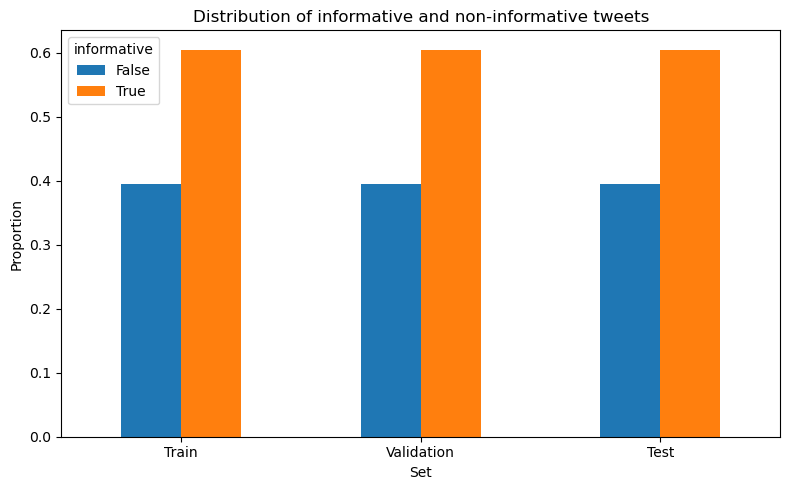

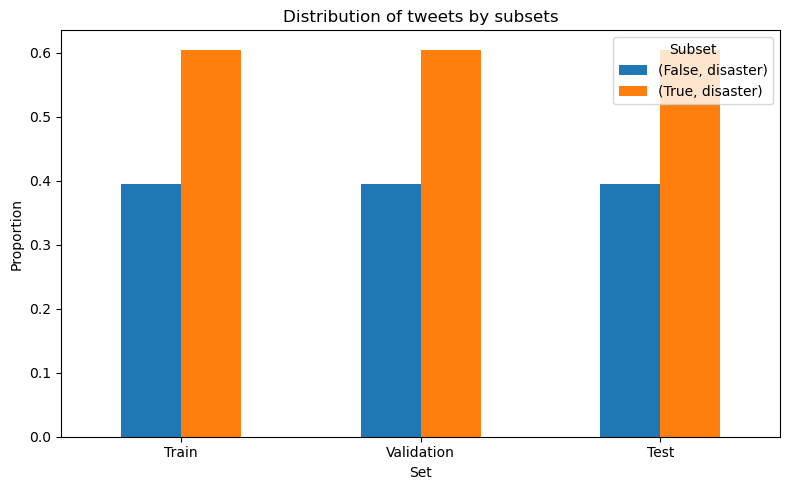

Weather ratio: 0.5, Out-topic ratio: 0
Informative dataset size: 9419


,tweet_text,informative,subset
0,The plane is scheduled to return later Friday ...,True,disaster
1,I need to just stay out of people's lives.,False,disaster
2,A plan has been elaborated in which four key h...,False,disaster
3,[Author: j-harvey] https://t.co/GYFw8FfjmO Jen...,False,disaster
4,@emlott7 @wayfarersprayer Donald called and sa...,False,disaster


6593
1413
1413
Train: 70.00%
Validation: 15.00%
Test: 15.00%


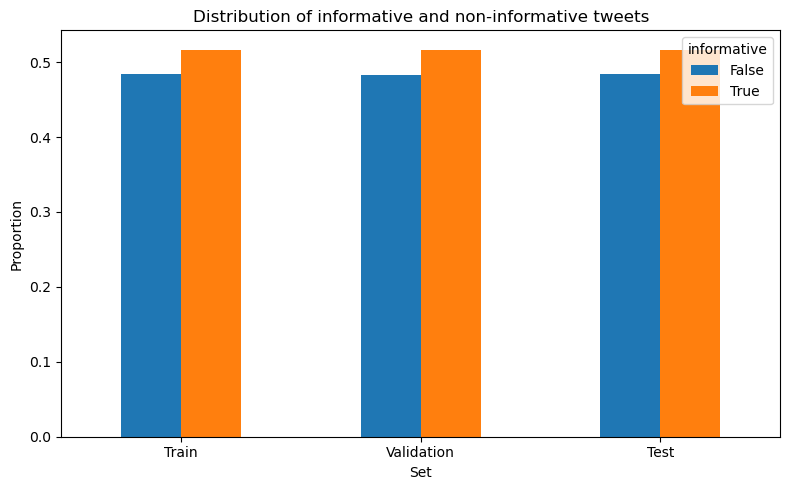

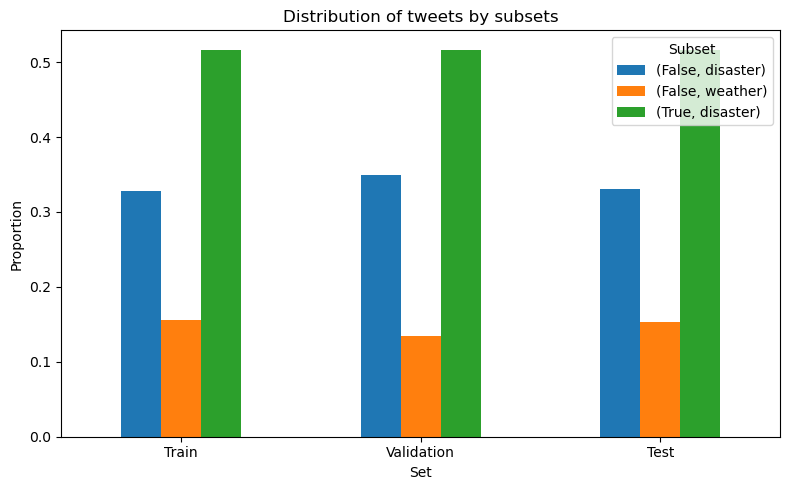

Weather ratio: 1, Out-topic ratio: 0.64
Informative dataset size: 239814


,tweet_text,informative,subset
0,Monica may start smashing stuff if they don't ...,False,out_topic
1,A wonderful day at the beach @schaecomspi...,False,out_topic
2,"Thanks. Yep, mistakes happen! RT @MrGeller: @r...",False,out_topic
3,"paint in you silver, wrap you in cold.",False,out_topic
4,gonna try and get some sleep. when did i start...,False,out_topic


167869
35972
35973
Train: 70.00%
Validation: 15.00%
Test: 15.00%


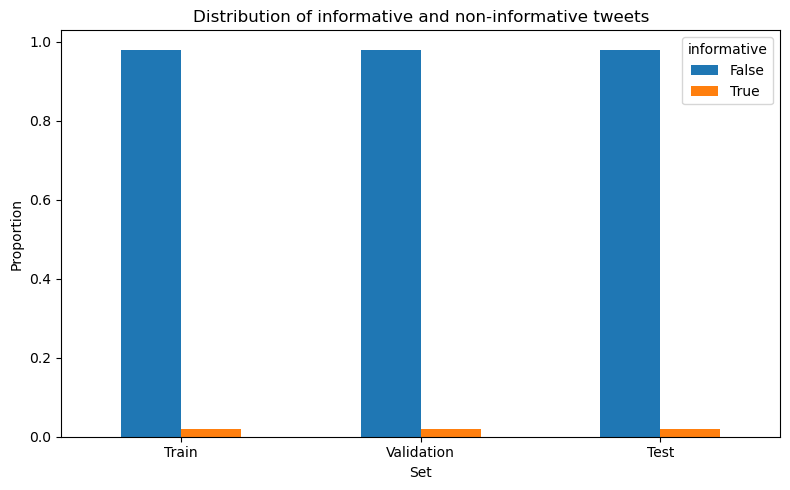

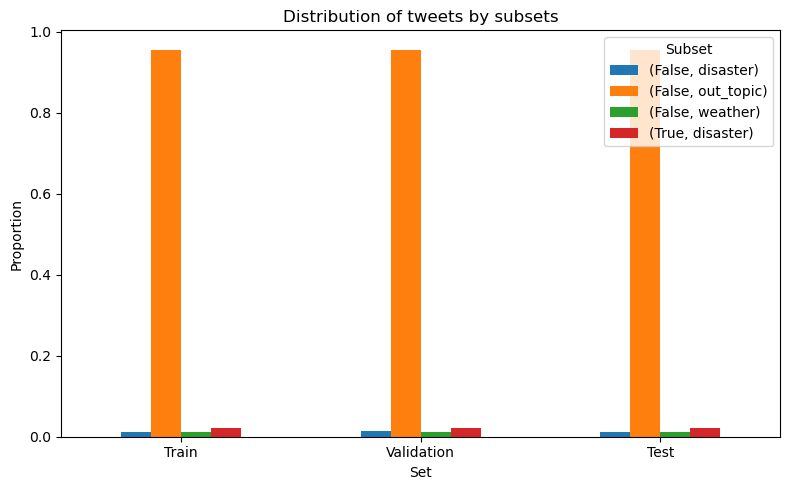

Weather ratio: 1, Out-topic ratio: 0.0109
Informative dataset size: 14750


,tweet_text,informative,subset
0,earthquake..pork barrel.. super typhoon.. the ...,True,disaster
1,Iâ€™m not going to get a white Christmas and u...,False,weather
2,RT @ChrisBarnes1994: I'm more certain climate ...,False,weather
3,If you get a second chance in life. Take advan...,False,disaster
4,Too head-coldy to go hiking today. Heating up...,False,out_topic


10325
2212
2213
Train: 70.00%
Validation: 15.00%
Test: 15.00%


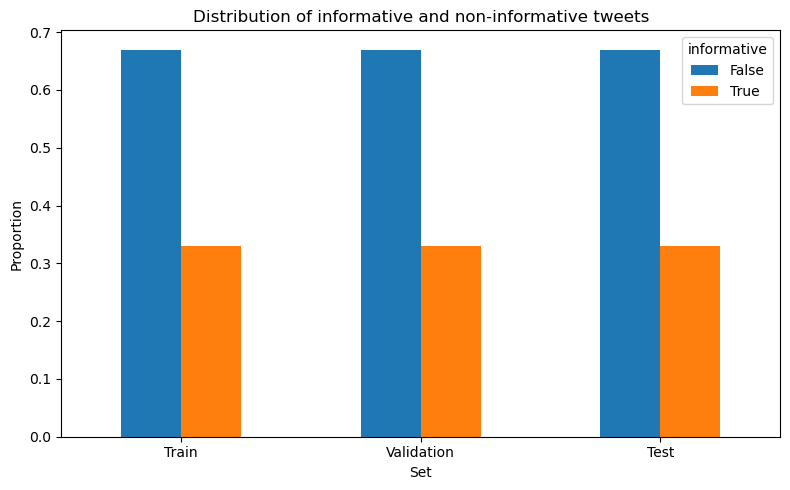

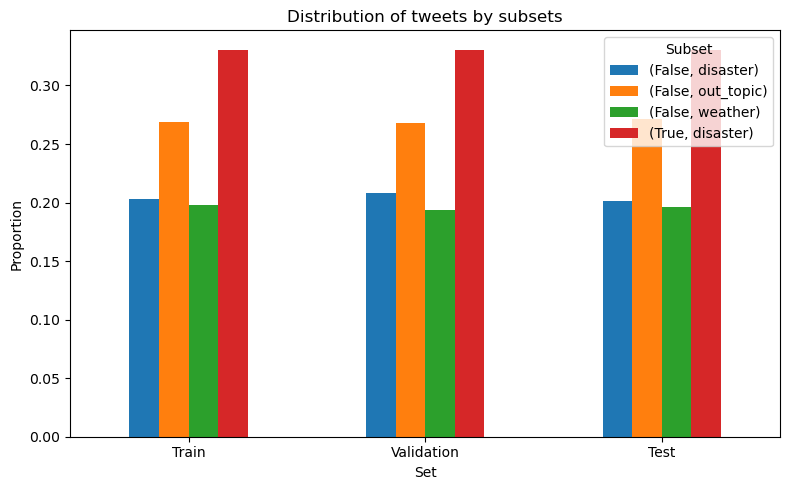

Weather ratio: 1, Out-topic ratio: 0.0199
Informative dataset size: 17970


,tweet_text,informative,subset
0,Al Gore and cronies continue getting richer fr...,False,weather
1,We attempted to consolidate this in the public...,False,disaster
2,my children are not dressed for today's weathe...,False,weather
3,#MM NEW MUSIC FROM HOOBANGIN/GREEN DIVISION AR...,False,out_topic
4,#Islamic #state issue a new holiday #brochure ...,False,disaster


12579
2695
2696
Train: 70.00%
Validation: 15.00%
Test: 15.00%


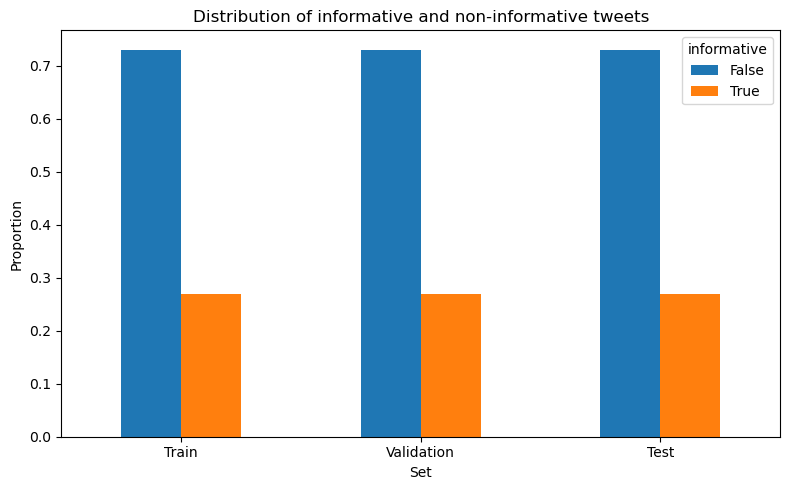

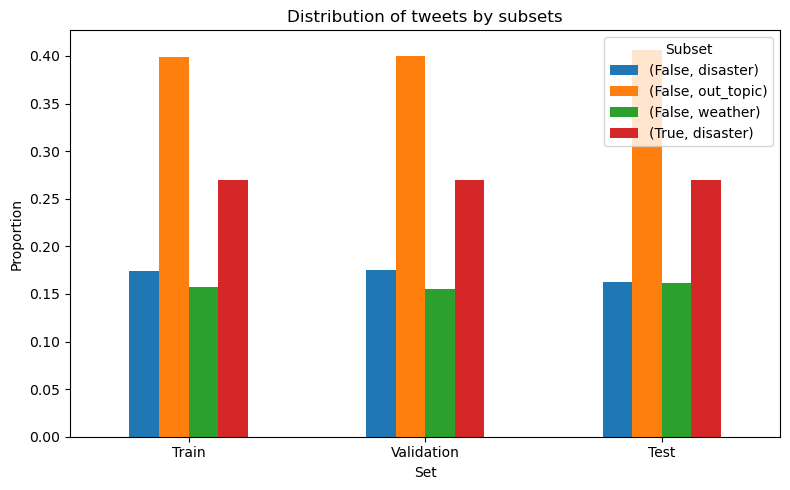

Weather ratio: 1, Out-topic ratio: 0.0425
Informative dataset size: 26055


,tweet_text,informative,subset
0,Is doing the thing she loves most with the peo...,False,out_topic
1,@tybonedher 8 ? 9? lol so gay lol! cus i have ...,False,out_topic
2,RT @CitysearchATL: Music pick of the day: Drea...,False,out_topic
3,With #TX08 Walker County Judge getting an upda...,True,disaster
4,@JayAckroyd ...as opposed to some universal pr...,False,out_topic


18238
3908
3909
Train: 70.00%
Validation: 15.00%
Test: 15.00%


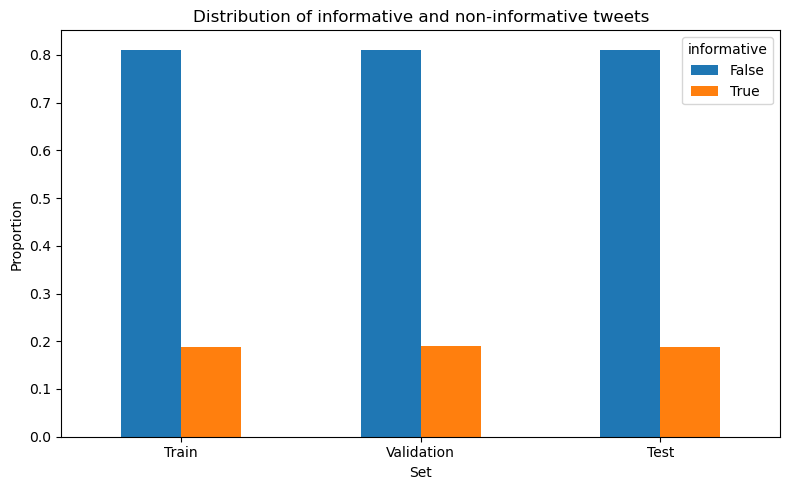

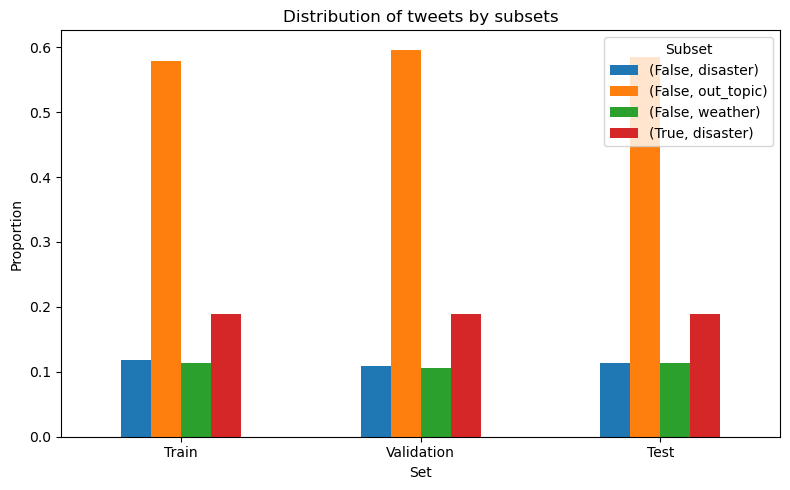

Weather ratio: 1, Out-topic ratio: 0.0876
Informative dataset size: 42190


,tweet_text,informative,subset
0,Señores de @116928 ... he llegado a la conclus...,False,out_topic
1,Slippy pa....haaaaay.....but i nid to wame up ...,False,out_topic
2,*standing in line at JoAnn's little girl and h...,False,disaster
3,Dispatch from Copenhagen today with 43 tonnes ...,True,disaster
4,here we go with the rain tweets #RubyPH,False,disaster


29533
6328
6329
Train: 70.00%
Validation: 15.00%
Test: 15.00%


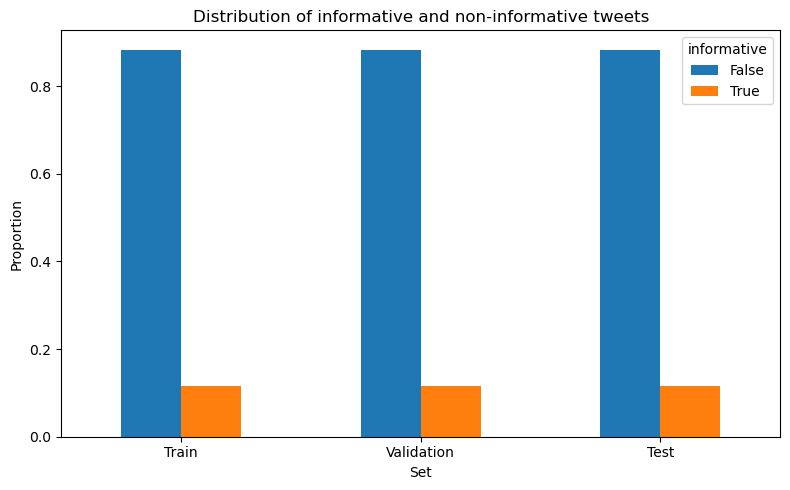

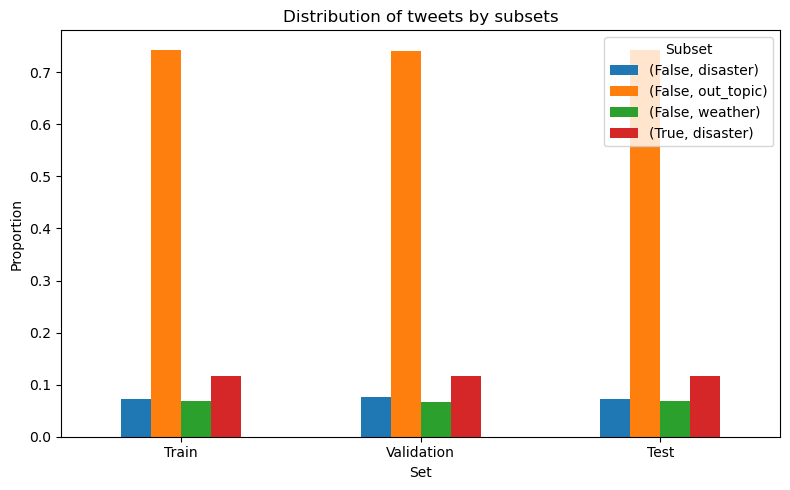

In [ ]:
for weather_ratio, out_topic_ratio in data_utils.EXPERIMENT_RATIOS:
    df_informative = load_datasets(
        df_disaster_sample,
        df_weather_original,
        df_out_topic_original,
        weather_ratio,
        out_topic_ratio,
    )

    print(f"Informative dataset size: {len(df_informative)}")
    display(df_informative.head())
    
    save_path = dataset_path/ 'splited' / data_utils.get_experiment_ratios_path(weather_ratio, out_topic_ratio)

    informative_dist, subset_dist = split_then_export_datasets(
        df_informative,
        validation_sizes=0.15,
        test_sizes=0.15,
        save_path=save_path
    )
    
    ax = informative_dist.T.plot(kind="bar", figsize=(8, 5), rot=0)
    ax.set_xlabel("Set")
    ax.set_ylabel("Proportion")
    ax.set_title("Distribution of informative and non-informative tweets")
    ax.legend(title="informative")
    plt.tight_layout()
    plt.show()
    
    ax = subset_dist.T.plot(kind="bar", figsize=(8, 5), rot=0)
    ax.set_xlabel("Set")
    ax.set_ylabel("Proportion")
    ax.set_title("Distribution of tweets by subsets")
    ax.legend(title="Subset")
    plt.tight_layout()
    plt.show()